# ベイズ推論
- パラメータ推定の方法
    - *頻度論：最尤推定法（パラメータの点推定、局所解にはまりやすい）*
    - *ベイズ流：ベイズ推定（パラメータの分布推定、計算に時間がかかる、収束しない場合がある）*

## 環境構築

In [ ]:
#%pip install -q graphviz

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


In [4]:
#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

## 推論

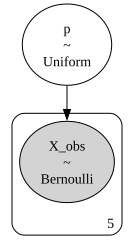

In [5]:
#-----------------------------------------------
#問題設定
#-----------------------------------------------
"""
くじ引きを引いた際に、「アタリ|ハズレ|ハズレ|アタリ|ハズレ」であった。
1回のくじ引きに当たる確率をpとするとき、このpの値を求める。
"""


#-----------------------------------------------
#最尤推定法
#-----------------------------------------------
"""
def lp(p):
    return p ** 2 * (1-p) ** 3

p = np.arange(0, 1, 0.01)

plt.rcParams['figure.figsize'] = (6, 4)
plt.plot(p, lp(p))
plt.xlabel('p(確率値)')
plt.ylabel('尤度')
plt.title('尤度関数')
plt.show()
"""

#-----------------------------------------------
#ベイズ推定
#-----------------------------------------------

#観測値
X = np.array([1, 0, 0, 1, 0])

#コンテキスト定義
model11 = pm.Model()
with model11:
    #pm.Uniform：一様分布
    p = pm.Uniform('p', lower=0.0, upper=1.0)
    
    X_obs = pm.Bernoulli('X_obs', p=p, observed=X)
    
g = pm.model_to_graphviz(model11)
display(g)